# **Homework1: Perceptrons**

 - Answer the questions marked with **Questions # )** . Just answer the parts where it says: **" write your answer here. "**
 > you can write the answers that are not code in a separate pdf file and attach it to this file but you should write the codes here in this notebook.
 * Questions that do not need coding: 1-a, 1-b, 2, 4, 8
 * Questions that need coding: 3, 5, 6, 7, 9, 10
 * Total score: 100 score and 35 bonus additive points
 * Bonus questions are optional and their score is additive only for this homework.

---



**Question 1-a ) (10 points)**  Construct by **hand** a Perceptron which correctly classifies the following data (a. and b. and c.); use your knowledge of plane geometry to choose appropriate values for the weights w0, w1 and w2. try to draw the result line if it exists.

Training Example | x1 | x2 | Class
--- | --- | --- | ---
a. | 0 | 1 | -1
b. | 2 | 0 | -1
c. | 1 | 1 | +1







***write your answer here***

---


---
**Question 1-b ) (10 points)**	Demonstrate by **hand** the Perceptron Learning Algorithm on the above data, using initial weight values of
w0=-1.5
w1=0
w2=2
In your answer, you should clearly indicate the new weight values at the end of each training step. Write the calculations and fill a table like this:


Iteration	| w0 |	w1 |	w2
--- | --- | --- | ---
1 | -1.5 | 0 | 2
2 | - | - | -
.
.
.


***write your answer here***

---


---
**Question 2 ) (10 points)** XOR Network:
Construct by **hand** a Neural Network (or Multi-Layer Perceptron) that computes the XOR function of two inputs. Make sure the connections, weights and biases of your network are clearly visible. ([XOR gates reference](https://en.wikipedia.org/wiki/XOR_gate))

Input | Output
--- | ---
0 0 | 0
0 1 | 1
1 0 | 1
1 1 | 0


***write your answer here***

---


Neccessary libraries are imported here and some variables are predefined.

In [1]:
import numpy as np
from numpy.random import randn
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# make the code reproducible
np.random.seed(5)
w=0
b=0

## Dataset

A predefined 2D dataset

In [2]:
# Define the dataset
X_train = np.array([[1.5, 0.7], [1.6, 1.0], [2.0, 0.8], [1.2, 1.5], [0.7, 1.6], [1.7, 1.0], [0.8, 1.9], [0.9, 0.8], [1.1, 1.3], [1.0, 1.5], [1.5, 3.5], [2.5, 2.0], [3.0, 1.6], [3.0, 2.5], [2.0, 3.0], [2.8, 1.4], [3.2, 3.4], [2.5, 2.5], [3.5, 2.2], [2.5, 3.2]])
y_train = np.array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, -1, -1, -1, -1, -1, -1, -1, -1, -1, -1])


## Visualize Data

---

**Question 3 ) (5 points)** Write a function that plots the predefined data using X_train and y_train in a 2D space. make the points that are tagged +1 red circles and the other points blue squares.

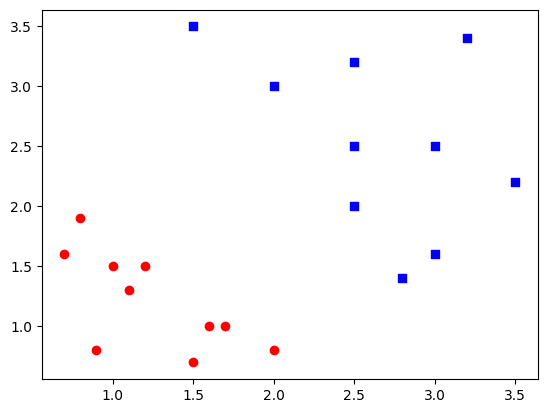

In [3]:
def plot_data(X,y):

  # write your answer here
    sample1 = X[y == 1]
    sample2 = X[y == -1]

    plt.scatter(sample1[:, 0], sample1[:, 1], marker='o', color='red')
    plt.scatter(sample2[:, 0], sample2[:, 1], marker='s', color='blue')

plot_data(X_train,y_train)

---

-------------------------------------------------------------------------------

**Question 4 ) (5 points)** Is this dataset linearly separable? explain your reason.

***write your answer here***

-------------------------------------------------------------------------------

## Example classifier line

---

**Question 5 ) (15 points)** First, define a function that takes
examples in the form of {(X,*y*)}, as well as parameters *w* and *b*. Then, plot the examples as scatter points and overlay the line given by *w.x+b*=0.
Then, through trial and error, find values for *w* and *b* such that the line *w.x+b*=0 separates all the points correctly.

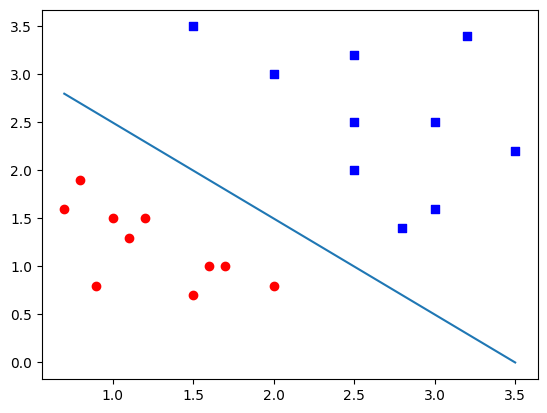

In [4]:
def plot_perceptron(X,y,w,b):

    # write your code here
    plot_data(X,y)
    
    # Line: w1 * x1 + w2 * x2 + b = 0
    w1, w2 = w
    if w2 != 0:
        slope = -w1 / w2
        y_intercept = -b / w2
    else:
        slope = None
        y_intercept = -b / w1
        
    x_range = (np.min(X[:, 0]), np.max(X[:, 0]))
    x1_line = np.linspace(*x_range, 50)
    if slope is not None:
        x2_line = slope * x1_line + y_intercept
    else:
        x2_line = np.full_like(x1_line, y_intercept)
        x2_line, x1_line = x1_line, x2_line
        
    plt.plot(x1_line, x2_line)
    return

# Find w and b through trial and error:
# w=?
# b=?
w = np.array([1, 1])
b = -3.5
plot_perceptron(X_train,y_train,w,b)

---

## Train a simple binary classifier perceptron

---

**Question 6 ) (20 points)** Implement the perceptron algorithm in a function that was mentioned in the slides 1.

Inputs to Perceptron are:
* X = data points
* Y = tags
* w_initial = initial guess of w
* b_initial = initial guess of b

optional inputs **(5 more bonus points for each argument implementation)**:
* maxchecks = maximum number of data points to look out, which may or may not violate the perceptron condition
* maxiters = maximum number of updates to w
* learning_rate

Perceptron should start with the input guess of w, look at most maxchecks data points and make at most maxiters updates, and return the final w and b.

Use plot_perceptron to plot you result with the new w and b.

reference: slide 33 from فصل اول: از نورون بیولوژیکی تا پرسپترون
   


Optimal weights: [-3.4 -4.8]
Optimal bias: 13.0


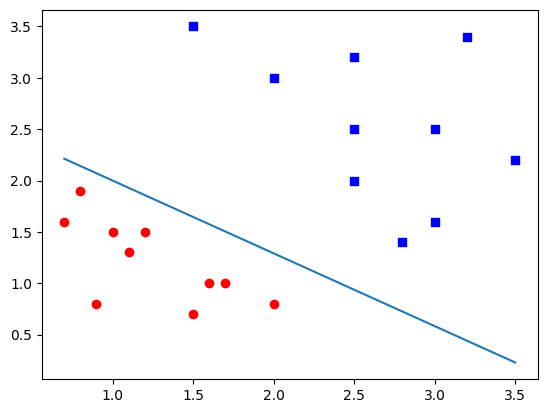

In [5]:
def train_perceptron(X, y, w_initial, b_initial, learning_rate=1.0, max_checks=0, maxiters=100):

    # write your answer here
    w = w_initial
    b = b_initial
    max_checks = max_checks if max_checks else len(X)
    
    for iteration in range(maxiters):
        for x, i in list(zip(X, y))[:max_checks]:
            a = np.matmul(w, x) + b
            prediction = -1 if a < 0 else 1   
            if prediction != i:
                w = w + (learning_rate * i * x)
                b = b + (learning_rate * i)
                break
        else:
            return w, b
    return w, b

X = X_train
y = y_train

w_initial = np.array([0, 0])
b_initial = 0

w, b = train_perceptron(X, y, w_initial, b_initial)
print("Optimal weights:", w)
print("Optimal bias:", b)

plot_perceptron(X,y,w,b)

---

## Another dataset

---

**Question 7 ) (15 points)** Try to write a function that creates two clusters of data using num_samples, their centroids and a standard deviation and run the train_perceptron function that you wrote on it. try to classify the points and plot the results like before.

Optimal weights: [0.1229355  0.22243525]
Optimal bias: -0.8999999999999999


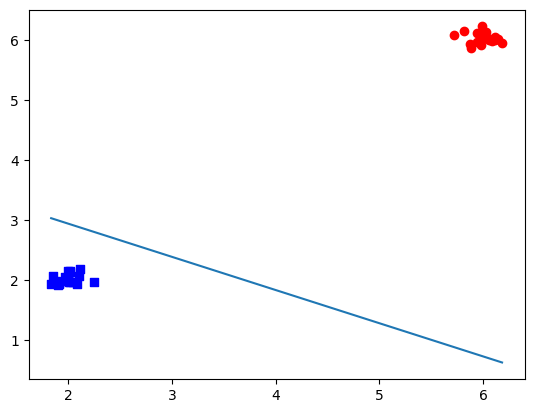

In [6]:
def create_blob(num_samples = 100, centroid1=[2, 2], centroid2=[6, 6], std=0.8):

    # write your answer here
    X1 = np.random.normal(loc=centroid1, scale=std, size=(num_samples, 2))
    X2 = np.random.normal(loc=centroid2, scale=std, size=(num_samples, 2))
    
    X = np.concatenate((X1, X2), axis=0)
    y = np.array([-1] * num_samples + [1] * num_samples)
    return X,y

X, y = create_blob(20, [2, 2], [6, 6], 0.1)

w_initial = np.array([0, 0])
b_initial = 0
learning_rate = 0.1

w, b = train_perceptron(X, y, w_initial, b_initial, learning_rate)
print("Optimal weights:", w)
print("Optimal bias:", b)

plot_perceptron(X,y,w,b)

---

-------------------------------------------------------------------------------

**Question 8 ) (10 points)** Explain how the perceptron training algorithm which was mentioned before ensures the convergence ( proof not needed just explain )?  Explain how size of data, dimension of data and diversity of data affect the results?




***write your answer here***

-------------------------------------------------------------------------------

# Bonus questions

---

**Question 9 ) (20 points)** Implement and explain one idea to make the perceptron function more flexible ( hint: how could you identify points that are persistently misclassified, or points whose updates cause many other points to become misclassified? )

Optimal weights: [0.35662971 0.7829664 ]
Optimal bias: -5


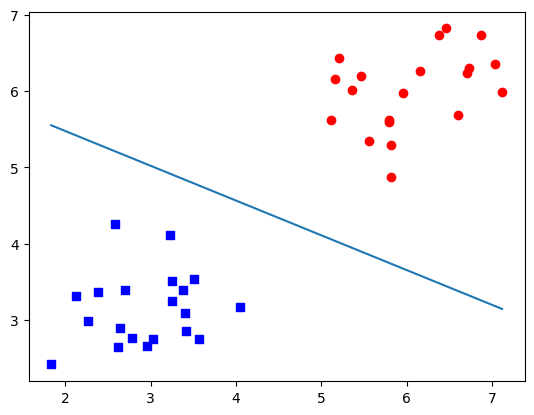

In [7]:
# write your answer here

def cal_misclassified(X, y, w, b):
    count = 0
    for x, i in zip(X, y):
        a = np.matmul(w, x) + b
        prediction = -1 if a < 0 else 1   
        if prediction != i:
            count += 1
    return count
    
def train_modified_perceptron(X, y, w_initial, b_initial, learning_rate=1.0, max_checks=0, maxiters=100):

    w = w_initial
    b = b_initial
    max_checks = max_checks if max_checks else len(X)
    
    for iteration in range(maxiters):
        misclassified = []
        for x, i in list(zip(X, y))[:max_checks]:
            a = np.matmul(w, x) + b
            prediction = -1 if a < 0 else 1   
            if prediction != i:
                w_hat = w + (learning_rate * i * x)
                b_hat = b + (learning_rate * i)
                count = cal_misclassified(X, y, w_hat, b_hat)
                misclassified.append((x, i, count))
                
        if len(misclassified):
            misclassified = sorted(misclassified, key=lambda x: x[2])
            x, i, count = misclassified[0]
            w = w + (learning_rate * i * x)
            b = b + (learning_rate * i)
        else:
            return w, b
    return w, b

X, y = create_blob(20, [3, 3], [6, 6], 0.5)

w_initial = np.array([0, 0])
b_initial = 0
learning_rate = 1

w, b = train_modified_perceptron(X, y, w_initial, b_initial, learning_rate)
print("Optimal weights:", w)
print("Optimal bias:", b)

plot_perceptron(X,y,w,b)

---